# Apresentação Final

Projeto de classificação supervisionada para detecção de indícios de câncer de mama em registros hospitalares do DATASUS SIH/SUS RJ 2025.

Esta versão foi organizada para apresentação, com foco em coerência narrativa e no target binário final.

## Fluxo da apresentação

1. Dados e redução da base
2. Tratamento e construção do target binário
3. Baseline, KNN, SVM e Random Forest
4. Métricas e interpretação
5. Conclusões e limitações

## Como usar

Use este notebook como apoio visual principal. As células foram reorganizadas para reduzir desvios e manter a narrativa centrada no target binário de câncer de mama.

## Problema e objetivo

**Problema:** identificar, em registros hospitalares do DATASUS, internações com indício de câncer de mama.

**Objetivo do projeto:** construir uma etapa de classificação supervisionada para apoiar triagem inicial.

**Pergunta central:** dado um registro hospitalar, o modelo consegue indicar se existe ou não indício de câncer de mama?

## Por que o target final é binário

Durante o tratamento dos CIDs, foi consolidada uma variável auxiliar para organizar os indícios encontrados.

Para a modelagem final, essa informação foi simplificada para um problema binário:
- **0:** sem indício
- **1:** com indício

Essa escolha faz sentido porque o objetivo do projeto é **triagem**. Em triagem, a pergunta principal não é o grau do caso, mas se ele deve ou não ser sinalizado para revisão.

## Preparação do ambiente

Execute esta célula antes do Bloco 1 para carregar a base consolidada e a base reduzida usadas na apresentação.

In [ ]:
import pandas as pd
import re
from pathlib import Path

candidate_consolidado = [
    Path('2025_consolidado.parquet'),
    Path('ia_tech_challenge_01/2025_consolidado.parquet'),
]
candidate_reduzido = [
    Path('2025_reduzido.parquet'),
    Path('ia_tech_challenge_01/2025_reduzido.parquet'),
]
candidate_tratado = [
    Path('2025_tratado.parquet'),
    Path('ia_tech_challenge_01/2025_tratado.parquet'),
]

path_consolidado = next((p for p in candidate_consolidado if p.exists()), None)
path_reduzido = next((p for p in candidate_reduzido if p.exists()), None)
path_tratado = next((p for p in candidate_tratado if p.exists()), None)

if path_consolidado is None:
    raise FileNotFoundError('Arquivo 2025_consolidado.parquet não encontrado')
if path_reduzido is None:
    raise FileNotFoundError('Arquivo 2025_reduzido.parquet não encontrado')
if path_tratado is None:
    raise FileNotFoundError('Arquivo 2025_tratado.parquet não encontrado')

dados = pd.read_parquet(path_consolidado)
df_reduzido = pd.read_parquet(path_reduzido)
dados_tratado = pd.read_parquet(path_tratado)

print('Base consolidada carregada:', path_consolidado)
print('Base reduzida carregada:', path_reduzido)
print('Base tratada carregada:', path_tratado)
print('dados.shape =', dados.shape)
print('df_reduzido.shape =', df_reduzido.shape)
print('dados_tratado.shape =', dados_tratado.shape)


---

## Bloco 1 - Dados, tratamento e target binário

### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs
#### Parte 1 - Dados Gerais - Redução do volume da base de dados

Fonte de dados escolhida: DATASUS  
Tipo de dados de origem: DBC

* Foram obtidos no site do SUS os dados de SIH/SUS - Sistema de Informações Hospitalares, arquivo RD - AIH Reduzida, do estado do Rio de Janeiro no ano de 2025.
* Os dados originais são disponibilizados em formato DBC e divididos por mês, com isso foi necessário:
    * Descompactá-los para o formato DBF
    * Realizar a conversão para o formato Parquet
        - Arquivos parquet conseguem otimizar o volume de dados facilitando seu tamanho e manipulação
    * Realizar o merge mês a mês para gerar o arquivo referente ao ano de 2025
    * O resultado foi o arquivo 2025_consolidado.parquet
    * Todas as ações anteriores não foram documentadas passo a passo aqui, pois não fazem parte do escopo geral da apresentação

---

## Sumário da Parte 1

**Objetivo geral - Redução do volume de dados**

Organizar a base SIH/SUS RD de 2025, avaliar sua estrutura inicial, manter apenas as colunas relevantes ao recorte analítico e gerar uma versão reduzida em Parquet para as próximas etapas de tratamento.

**Item 1 - Leitura estrutural da base consolidada**

- **1.1 - Carregamento e amostra inicial**
- **1.2 - Descrição estatística da base**
- **1.3 - Dimensões da base consolidada**
- **1.4 - Tipos de dados e uso de memória**

**Item 2 - Dicionário de Dados - SIH/SUS RD - AIH Reduzida**

- **2.1 - Consulta das colunas originais**
- **2.2 - Entendimento semântico dos campos**

**Item 3 - Remoção de colunas não utilizadas**

- **3.1 - Definição das colunas mantidas**
- **3.2 - Registro das colunas removidas**
- **3.3 - Geração da base reduzida**

**Item 4 - Validação da base reduzida**

- **4.1 - Conferência das colunas finais**
- **4.2 - Conferência do shape final**


##### 1.3 - Dimensões da base consolidada

Registro do volume original antes da remoção de colunas.


In [3]:
dados.shape

(925240, 114)

#### Item 4 - Validação da base reduzida

**Neste passo vamos:**

- **4.1 - Conferir as colunas finais** gravadas no arquivo `2025_reduzido.parquet`.
- **4.2 - Conferir o shape final** para validar se a redução preservou a quantidade de registros esperada.


In [7]:
df_reduzido.shape

(925240, 55)

#### Item 2 - Verificação dos nulos

**Neste passo vamos:**

- **2.1 - Avaliar dados nulos e vazios**
- **2.2 - Tratar os dados nulos e vazios**


In [4]:
dados.isna().sum()

MES_CMPT      0
IDENT         0
MUNIC_RES     0
NASC          0
SEXO          0
COD_IDADE     0
IDADE         0
NUM_FILHOS    0
INSTRU        0
GESTRISCO     0
CONTRACEP1    0
CONTRACEP2    0
RACA_COR      0
ETNIA         0
MUNIC_MOV     0
DT_INTER      0
DT_SAIDA      0
DIAS_PERM     0
QT_DIARIAS    0
UTI_MES_IN    0
UTI_MES_AN    0
UTI_MES_AL    0
UTI_MES_TO    0
UTI_INT_IN    0
UTI_INT_AN    0
UTI_INT_AL    0
UTI_INT_TO    0
MORTE         0
PROC_REA      0
DIAG_PRINC    0
DIAG_SECUN    0
CID_NOTIF     0
CID_ASSO      0
CID_MORTE     0
DIAGSEC1      0
DIAGSEC2      0
DIAGSEC3      0
DIAGSEC4      0
DIAGSEC5      0
DIAGSEC6      0
DIAGSEC7      0
DIAGSEC8      0
DIAGSEC9      0
TPDISEC1      0
TPDISEC2      0
TPDISEC3      0
TPDISEC4      0
TPDISEC5      0
TPDISEC6      0
TPDISEC7      0
TPDISEC8      0
TPDISEC9      0
COMPLEX       0
VAL_TOT       0
DIAR_ACOM     0
dtype: int64

##### 2.2 - Tratamento de nulos e vazios

Podemos observar que não há valores nulos, mas há colunas com registros vazios, todas relacionadas aos CIDs. Faremos a tratativa dos CIDs em etapa posterior.


##### 3.1 - Recorte das internações do ano de 2025


In [7]:
dados = dados[dados["DT_INTER"].str[0:4]=='2025']

##### 3.3 - Tratamento da coluna idade


**Nossos dados referentes à idade estão tratados e confiáveis.**


#### Item 5 - Tratamento dos campos CID

**Tratamento dos campos CID**

Neste passo vamos:

- **5.1 - Avaliar CIDs inválidos em todos os campos CID mantidos no recorte**
- **5.2 - Gerar representações numéricas para todos os campos CID**
- **5.3 - Categorizar o CID do diagnóstico principal por capítulo/tema clínico**
- Usar todos os campos CID para identificar indícios de violência contra mulher e câncer de mama em etapas posteriores.

Padrão CID usado na validação:

- 1 letra
- 2 números
- opcionalmente 1 ou 2 caracteres alfanuméricos


In [18]:
colunas_cid = [
    'DIAG_PRINC', 'DIAG_SECUN', 'CID_ASSO', 'CID_NOTIF',
    'DIAGSEC1', 'DIAGSEC2', 'DIAGSEC3', 'DIAGSEC4', 'DIAGSEC5',
    'DIAGSEC6', 'DIAGSEC7', 'DIAGSEC8', 'DIAGSEC9', 'CID_MORTE'
]

print('Campos CID considerados na consolidação do indício:')
print(colunas_cid)


#### Item 6 - Identificação de indícios de câncer de mama em todos os campos CID

**Neste passo consolidamos os indícios encontrados nos campos CID para sustentar a geração do target binário final de classificação.**

**Para a apresentação, a leitura deve ser feita assim:**

- **0 - Sem indício**
- **1 - Com indício**


In [25]:
print('Distribuição da variável auxiliar que sustenta o target binário:')
dados_tratado.groupby('CANCER_MAMA_NIVEL').size()


CANCER_MAMA_NIVEL
0    848560
1       920
2       174
3      8072
dtype: int64

#### Item 8 - Geração da base tratada final

**Neste passo vamos:**

- **8.1 - Remover colunas temporárias e que não serão utilizadas**
- **8.2 - Gerar arquivo Parquet final tratado**
- **8.3 - Validar tipos finais, colunas finais e estrutura da base tratada**

A base tratada lógica contém **857.726 registros** e **74 colunas de dados** após o recorte de internações com `DT_INTER` em 2025, remoção de `ETNIA`, criação de variáveis derivadas e remoção das flags auxiliares que não serão usadas. No arquivo Parquet salvo pode aparecer a coluna técnica `__index_level_0__`, criada pela gravação do índice do DataFrame; ela não representa uma variável analítica.



##### Dicionário de Dados - base tratada final

| Ordem | Coluna | Tipo | Descrição |
|---:|---|---|---|
| 1 | MES_CMPT | str | Mês de competência/processamento da informação. |
| 2 | IDENT | str | Identificação do tipo de AIH. |
| 3 | MUNIC_RES | str | Código IBGE do município de residência do paciente. |
| 4 | NASC | str | Data de nascimento original no formato aaaammdd. |
| 5 | SEXO | str | Sexo do paciente no código original. |
| 6 | COD_IDADE | str | Unidade de medida da idade original. |
| 7 | IDADE | int64 | Idade original conforme COD_IDADE. |
| 8 | NUM_FILHOS | int64 | Quantidade de filhos informada. |
| 9 | INSTRU | str | Grau de instrução. |
| 10 | GESTRISCO | str | Indicador de gestante de alto risco. |
| 11 | CONTRACEP1 | str | Método contraceptivo 1. |
| 12 | CONTRACEP2 | str | Método contraceptivo 2. |
| 13 | RACA_COR | str | Raça/cor do paciente. |
| 14 | DT_INTER | str | Data da internação. |
| 15 | DT_SAIDA | str | Data de saída/alta. |
| 16 | DIAS_PERM | int64 | Quantidade de dias de permanência. |
| 17 | QT_DIARIAS | int64 | Quantidade de diárias da internação. |
| 18 | UTI_MES_IN | int64 | Dias de UTI no mês inicial. |
| 19 | UTI_MES_AN | int64 | Dias de UTI em mês anterior ao mês da alta. |
| 20 | UTI_MES_AL | int64 | Dias de UTI no mês da alta. |
| 21 | UTI_MES_TO | int64 | Total de dias/atos de UTI. |
| 22 | UTI_INT_IN | int64 | Dias em unidade intermediária no mês inicial. |
| 23 | UTI_INT_AN | int64 | Dias em unidade intermediária em mês anterior ao mês da alta. |
| 24 | UTI_INT_AL | int64 | Dias em unidade intermediária no mês da alta. |
| 25 | UTI_INT_TO | int64 | Total de dias em unidade intermediária. |
| 26 | MORTE | int64 | Indicador de óbito. |
| 27 | PROC_REA | str | Código do procedimento realizado. |
| 28 | DIAG_PRINC | str | CID do diagnóstico principal. |
| 29 | DIAG_SECUN | str | CID do diagnóstico secundário. |
| 30 | CID_NOTIF | str | CID de notificação. |
| 31 | CID_ASSO | str | CID associado/causa. |
| 32 | CID_MORTE | str | CID associado ao óbito. |
| 33 | DIAGSEC1 | str | CID secundário 1. |
| 34 | DIAGSEC2 | str | CID secundário 2. |
| 35 | DIAGSEC3 | str | CID secundário 3. |
| 36 | DIAGSEC4 | str | CID secundário 4. |
| 37 | DIAGSEC5 | str | CID secundário 5. |
| 38 | DIAGSEC6 | str | CID secundário 6. |
| 39 | DIAGSEC7 | str | CID secundário 7. |
| 40 | DIAGSEC8 | str | CID secundário 8. |
| 41 | DIAGSEC9 | str | CID secundário 9. |
| 42 | TPDISEC1 | str | Tipo/classificação do diagnóstico secundário 1. |
| 43 | TPDISEC2 | str | Tipo/classificação do diagnóstico secundário 2. |
| 44 | TPDISEC3 | str | Tipo/classificação do diagnóstico secundário 3. |
| 45 | TPDISEC4 | str | Tipo/classificação do diagnóstico secundário 4. |
| 46 | TPDISEC5 | str | Tipo/classificação do diagnóstico secundário 5. |
| 47 | TPDISEC6 | str | Tipo/classificação do diagnóstico secundário 6. |
| 48 | TPDISEC7 | str | Tipo/classificação do diagnóstico secundário 7. |
| 49 | TPDISEC8 | str | Tipo/classificação do diagnóstico secundário 8. |
| 50 | TPDISEC9 | str | Tipo/classificação do diagnóstico secundário 9. |
| 51 | COMPLEX | str | Complexidade do procedimento/atendimento. |
| 52 | VAL_TOT | float64 | Valor total aprovado/pago da AIH. |
| 53 | DIAR_ACOM | int64 | Quantidade de diárias de acompanhante. |
| 54 | NASC_DT | datetime64[us] | Data de nascimento convertida para formato datetime. |
| 55 | ANO_NASC | int32 | Ano de nascimento derivado de NASC_DT. |
| 56 | IDADE_ANOS | int64 | Idade padronizada em anos. |
| 57 | DIAG_SECUN_VALIDA | bool | Flag de validação do formato CID para DIAG_SECUN. |
| 58 | DIAG_PRINC_INT | int64 | Representação numérica derivada de DIAG_PRINC. |
| 59 | DIAG_SECUN_INT | int64 | Representação numérica derivada de DIAG_SECUN. |
| 60 | CID_ASSO_INT | int64 | Representação numérica derivada de CID_ASSO. |
| 61 | CID_NOTIF_INT | int64 | Representação numérica derivada de CID_NOTIF. |
| 62 | DIAGSEC1_INT | int64 | Representação numérica derivada de DIAGSEC1. |
| 63 | DIAGSEC2_INT | int64 | Representação numérica derivada de DIAGSEC2. |
| 64 | DIAGSEC3_INT | int64 | Representação numérica derivada de DIAGSEC3. |
| 65 | DIAGSEC4_INT | int64 | Representação numérica derivada de DIAGSEC4. |
| 66 | DIAGSEC5_INT | int64 | Representação numérica derivada de DIAGSEC5. |
| 67 | DIAGSEC6_INT | int64 | Representação numérica derivada de DIAGSEC6. |
| 68 | DIAGSEC7_INT | int64 | Representação numérica derivada de DIAGSEC7. |
| 69 | DIAGSEC8_INT | int64 | Representação numérica derivada de DIAGSEC8. |
| 70 | DIAGSEC9_INT | int64 | Representação numérica derivada de DIAGSEC9. |
| 71 | CID_MORTE_INT | int64 | Representação numérica derivada de CID_MORTE. |
| 72 | DIAG_PRINC_GRUPO | int64 | Agrupamento do diagnóstico principal por capítulo/letra CID. |
| 73 | CANCER_MAMA_NIVEL | int64 | Variável auxiliar construída a partir dos CIDs para apoiar a geração do target binário final de indício de câncer de mama. |

---

## Bloco 2 - Definição do target, baseline e KNN

## Por que accuracy sozinha engana

A base é fortemente desbalanceada: quase 99% dos registros estão na classe negativa.

Isso significa que um modelo pode ter accuracy muito alta simplesmente prevendo quase tudo como negativo.

Por isso, nesta apresentação, a leitura dos resultados prioriza principalmente:
- **recall**, para medir quantos positivos reais foram encontrados
- **matriz de confusão**, para enxergar os falsos negativos
- **F1** e **AUC**, como métricas complementares

### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs

#### Parte 4 - Classificação supervisionada: detecção de indícios de câncer de mama

Este notebook implementa a etapa de classificação supervisionada usando a base tratada do DATASUS (SIH/SUS RJ 2025).
O objetivo é criar um target binário a partir de `CANCER_MAMA_NIVEL > 0`, preparar os dados com `Pipeline` e `ColumnTransformer` e comparar um baseline ingênuo, uma regressão logística e um KNN.

## Sumário da Parte 4

#### Item 1 - Definição do target
#### Item 2 - Preparação dos dados
#### Item 3 - Separação entre treino e teste
#### Item 4 - Pipeline e treinamento dos modelos
#### Item 5 - Avaliação dos modelos
#### Item 6 - Comparação dos resultados
#### Item 7 - Validação cruzada
#### Item 8 - ROC e AUC
#### Conclusão da Parte 4


#### Item 1 - Definição do target

Vamos criar a variável binária `TARGET`: 0 significa sem indício e 1 significa com indício de câncer de mama.

## Regra de decisão final dos modelos

A curva ROC foi usada para comparar a capacidade geral de separação dos modelos probabilísticos.

Mas a escolha da regra final de decisão **não foi chutada**:
- nos modelos probabilísticos, o ponto de corte foi estimado no conjunto de validação com base na curva **precision-recall**
- no KNN, não houve threshold; o que foi ajustado foi o valor de **k**

A tabela abaixo resume essa decisão final para cada modelo.

In [ ]:
decision_rows = [
    {
        'Modelo': 'Baseline (Logistic Regression)',
        'Tipo de decisao': 'threshold',
        'Valor escolhido': 0.6314,
        'Como foi definido': 'validacao via precision-recall',
    },
    {
        'Modelo': 'Random Forest',
        'Tipo de decisao': 'threshold',
        'Valor escolhido': 0.6506,
        'Como foi definido': 'validacao via precision-recall',
    },
    {
        'Modelo': 'KNN',
        'Tipo de decisao': 'k',
        'Valor escolhido': 3,
        'Como foi definido': 'desempenho na validacao',
    },
]

pd.DataFrame(decision_rows)


## Como chegamos ao threshold da Regressão Logística

O valor **0.6314** foi estimado no conjunto de validação, não escolhido manualmente.

O processo foi este:
1. treinamos a Regressão Logística em uma parte do treino
2. usamos `predict_proba` no conjunto de validação
3. geramos vários thresholds possíveis com a curva **precision-recall**
4. calculamos `precision`, `recall` e `F1` para cada threshold
5. filtramos apenas os thresholds com **recall >= 0.75**
6. entre esses candidatos, escolhemos o de **maior precision**
7. em caso de empate, usamos o **maior F1**

Esse critério levou ao threshold final de **0.6314**.

In [ ]:
criterio_threshold_log = pd.DataFrame([
    {
        'Etapa': '1',
        'Descricao': 'gerar thresholds com precision-recall no conjunto de validacao'
    },
    {
        'Etapa': '2',
        'Descricao': 'manter apenas thresholds com recall >= 0.75'
    },
    {
        'Etapa': '3',
        'Descricao': 'escolher o candidato com maior precision'
    },
    {
        'Etapa': '4',
        'Descricao': 'em empate, usar maior F1'
    },
    {
        'Etapa': 'Resultado',
        'Descricao': 'threshold final da Logistic Regression = 0.6314'
    },
])

criterio_threshold_log


Arquivo localizado em: /home/visheuleer/Desktop/Post-graduate/ia_tech_challenge_01/2025_tratado.parquet
Dimensões da base tratada: (857726, 76)
Distribuição do target:
TARGET
0    848560
1      9166
Name: count, dtype: int64

Proporção do target:
TARGET
0    0.989314
1    0.010686
Name: proporcao, dtype: float64


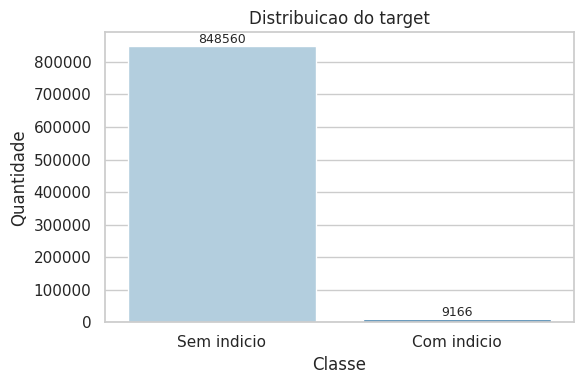

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

candidate_paths = [
    Path('2025_tratado.parquet'),
    Path('ia_tech_challenge_01/2025_tratado.parquet'),
    Path('/content/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/2025_tratado.parquet'),
    Path('/content/drive/MyDrive/ia_tech_challenge_01/2025_tratado.parquet'),
]

path = next((candidate for candidate in candidate_paths if candidate.exists()), None)
if path is None:
    searched = '\n'.join(f'- {candidate}' for candidate in candidate_paths)
    raise FileNotFoundError(
        'Arquivo de base tratada não encontrado. Verifique onde o arquivo '
        "'2025_tratado.parquet' foi salvo e ajuste o caminho na célula.\n"
        f'Caminhos verificados:\n{searched}'
    )

print(f'Arquivo localizado em: {path.resolve()}')
dados = pd.read_parquet(path)
TARGET = 'TARGET'
dados[TARGET] = (dados['CANCER_MAMA_NIVEL'] > 0).astype(int)

print('Dimensões da base tratada:', dados.shape)
print('Distribuição do target:')
print(dados[TARGET].value_counts().sort_index())
print('\nProporção do target:')
print(dados[TARGET].value_counts(normalize=True).sort_index().rename('proporcao'))

target_plot = dados[TARGET].value_counts().sort_index().rename_axis('Classe').reset_index(name='Quantidade')
target_plot['Classe'] = target_plot['Classe'].map({0: 'Sem indicio', 1: 'Com indicio'})

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=target_plot, x='Classe', y='Quantidade', hue='Classe', palette='Blues', legend=False)
ax.set_title('Distribuicao do target')
ax.set_xlabel('Classe')
ax.set_ylabel('Quantidade')
for patch in ax.patches:
    ax.annotate(f"{int(patch.get_height())}", (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


#### Item 2 - Preparação dos dados

A seleção de variáveis prioriza atributos demográficos, administrativos e de utilização hospitalar.
Variáveis diretamente derivadas de diagnóstico foram evitadas para reduzir vazamento de target.

In [13]:
feature_candidates = [
    'IDADE_ANOS',
    'DIAS_PERM',
    'QT_DIARIAS',
    'UTI_MES_IN',
    'UTI_MES_AN',
    'UTI_MES_AL',
    'UTI_MES_TO',
    'UTI_INT_IN',
    'UTI_INT_AN',
    'UTI_INT_AL',
    'UTI_INT_TO',
    'DIAR_ACOM',
    'SEXO',
    'RACA_COR',
    'GESTRISCO',
    'CONTRACEP1',
    'CONTRACEP2',
    'PROC_REA'
]

leakage_columns = [
    'CANCER_MAMA_NIVEL',
    'DIAG_PRINC',
    'DIAGSEC1',
    'DIAGSEC2',
    'DIAGSEC3',
    'DIAGSEC4',
    'DIAGSEC5',
    'DIAGSEC6',
    'DIAGSEC7',
    'CID_MORTE',
    'DIAG_PRINC_GRUPO'
]

features = [col for col in feature_candidates if col in dados.columns]
leakage_present = [col for col in leakage_columns if col in dados.columns]

numerical_features = [col for col in features if dados[col].dtype.kind in 'biufc']
categorical_features = [col for col in features if col not in numerical_features]

low_cardinality_features = []
high_cardinality_features = []
for col in categorical_features:
    nunique = dados[col].nunique(dropna=False)
    if nunique <= 20:
        low_cardinality_features.append(col)
    else:
        high_cardinality_features.append(col)

selected_features = numerical_features + low_cardinality_features
X = dados[selected_features].copy()
y = dados[TARGET].copy()

print('Features selecionadas para modelagem:')
print(features)

print('\nColunas sensíveis identificadas e excluídas da modelagem:')
print(leakage_present)

print('\nFeatures numéricas:', numerical_features)
print('Features categóricas de baixa cardinalidade:', low_cardinality_features)
print('Features categóricas excluídas por alta cardinalidade:', high_cardinality_features)

print('\nDimensões de X e y:', X.shape, y.shape)


Features selecionadas para modelagem:
['IDADE_ANOS', 'DIAS_PERM', 'QT_DIARIAS', 'UTI_MES_IN', 'UTI_MES_AN', 'UTI_MES_AL', 'UTI_MES_TO', 'UTI_INT_IN', 'UTI_INT_AN', 'UTI_INT_AL', 'UTI_INT_TO', 'DIAR_ACOM', 'SEXO', 'RACA_COR', 'GESTRISCO', 'CONTRACEP1', 'CONTRACEP2', 'PROC_REA']

Colunas sensíveis identificadas e excluídas da modelagem:
['CANCER_MAMA_NIVEL', 'DIAG_PRINC', 'DIAGSEC1', 'DIAGSEC2', 'DIAGSEC3', 'DIAGSEC4', 'DIAGSEC5', 'DIAGSEC6', 'DIAGSEC7', 'CID_MORTE', 'DIAG_PRINC_GRUPO']


#### Item 3 - Separação entre treino e teste

Usamos `train_test_split` com `stratify=y` para preservar a proporção de classes entre treino e teste.

#### Item 4 - Pipeline e treinamento dos modelos

As variáveis numéricas recebem imputação pela mediana e padronização com `StandardScaler`.
As categóricas de baixa cardinalidade recebem imputação e `OneHotEncoder`.

Serão comparados três modelos:
- `LogisticRegression` como baseline, com `class_weight='balanced'`
- `KNeighborsClassifier` como modelo principal, com ajuste simples de `k`
- `RandomForestClassifier` como alternativa baseada em árvores

Para os modelos probabilísticos, o `threshold` será definido a partir do conjunto de validação usando a curva de `precision-recall`, em vez de escolha manual.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('Treino:', X_train.shape, 'Teste:', X_test.shape)
print('Proporção de classes no treino:')
print(y_train.value_counts(normalize=True).sort_index())
print('Proporção de classes no teste:')
print(y_test.value_counts(normalize=True).sort_index())

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, precision_recall_curve, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', onehot),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_features),
    ('cat', categorical_transformer, low_cardinality_features),
])

X_fit_log, X_val_log, y_fit_log, y_val_log = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

X_train_knn, _, y_train_knn, _ = train_test_split(
    X_train,
    y_train,
    train_size=min(100_000, len(X_train)),
    random_state=42,
    stratify=y_train,
)

X_fit_knn, X_val_knn, y_fit_knn, y_val_knn = train_test_split(
    X_train_knn,
    y_train_knn,
    test_size=0.2,
    random_state=42,
    stratify=y_train_knn,
)

print('Amostra de treino para KNN:', X_train_knn.shape)

def calcular_metricas_por_threshold(y_true, y_scores):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
    rows = []
    for threshold, precision, recall, f1 in zip(thresholds, precisions[:-1], recalls[:-1], f1_scores):
        rows.append({
            'Threshold': float(threshold),
            'Precision': float(precision),
            'Recall': float(recall),
            'F1': float(f1),
        })
    return pd.DataFrame(rows)

def selecionar_threshold_por_precision_com_recall_alto(metricas_threshold, recall_minimo=0.75):
    candidatos = metricas_threshold[metricas_threshold['Recall'] >= recall_minimo].copy()

    if candidatos.empty:
        candidatos = metricas_threshold.copy()
        print(
            f"Nenhum threshold atingiu recall mínimo de {recall_minimo:.2f}. "
            "Usando o melhor recall disponível."
        )

        candidatos = candidatos.sort_values(
            by=['Recall', 'Precision', 'F1'],
            ascending=[False, False, False]
        )
    else:
        candidatos = candidatos.sort_values(
            by=['Precision', 'Recall', 'F1'],
            ascending=[False, False, False]
        )

    linha = candidatos.iloc[0]

    return (
        float(linha['Threshold']),
        float(linha['Precision']),
        float(linha['Recall']),
        float(linha['F1'])
    )

tuning_rows = []
threshold_rows = []
model_configs = {}

logistic_validation_model = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
])
logistic_validation_model.fit(X_fit_log, y_fit_log)
val_scores_log = logistic_validation_model.predict_proba(X_val_log)[:, 1]
log_threshold_df = calcular_metricas_por_threshold(y_val_log, val_scores_log)
log_threshold_df['Modelo'] = 'Baseline (Logistic Regression)'
threshold_rows.extend(log_threshold_df.to_dict(orient='records'))
best_threshold_log, best_precision_log, best_recall_log, best_f1_log = selecionar_threshold_por_precision_com_recall_alto(
    log_threshold_df,
    recall_minimo=0.75
)
tuning_rows.append({
    'Modelo': 'Baseline (Logistic Regression)',
    'Parametro': f'threshold={best_threshold_log:.4f}',
    'Precision': best_precision_log,
    'Recall': best_recall_log,
    'F1': best_f1_log,
})
print(f'Melhor threshold para Logistic Regression: {best_threshold_log:.4f}')

model_configs['Baseline (Logistic Regression)'] = {
    'pipeline': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ]),
    'threshold': best_threshold_log,
}
model_configs['Baseline (Logistic Regression)']['pipeline'].fit(X_train, y_train)
print('Baseline (Logistic Regression) treinado com sucesso')

best_k = None
best_knn_metrics = None
for k in [3, 5, 9, 15]:
    knn_validation_model = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', KNeighborsClassifier(n_neighbors=k)),
    ])
    knn_validation_model.fit(X_fit_knn, y_fit_knn)
    y_val_pred = knn_validation_model.predict(X_val_knn)
    precision = precision_score(y_val_knn, y_val_pred, zero_division=0)
    recall = recall_score(y_val_knn, y_val_pred, zero_division=0)
    f1 = f1_score(y_val_knn, y_val_pred, zero_division=0)
    tuning_rows.append({
        'Modelo': 'KNN',
        'Parametro': f'k={k}',
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
    })
    current_metrics = (f1, recall, precision)
    if best_knn_metrics is None or current_metrics > best_knn_metrics:
        best_knn_metrics = current_metrics
        best_k = k

print(f'Melhor valor de k para KNN: {best_k}')

model_configs['KNN'] = {
    'pipeline': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', KNeighborsClassifier(n_neighbors=best_k)),
    ]),
    'threshold': None,
}
model_configs['KNN']['pipeline'].fit(X_train_knn, y_train_knn)
print('KNN treinado com sucesso em amostra estratificada do treino')

rf_validation_model = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        min_samples_leaf=10,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1,
    )),
])
rf_validation_model.fit(X_fit_log, y_fit_log)
val_scores_rf = rf_validation_model.predict_proba(X_val_log)[:, 1]
rf_threshold_df = calcular_metricas_por_threshold(y_val_log, val_scores_rf)
rf_threshold_df['Modelo'] = 'Random Forest'
threshold_rows.extend(rf_threshold_df.to_dict(orient='records'))
best_threshold_rf, best_precision_rf, best_recall_rf, best_f1_rf = selecionar_threshold_por_precision_com_recall_alto(
    rf_threshold_df,
    recall_minimo=0.75
)
tuning_rows.append({
    'Modelo': 'Random Forest',
    'Parametro': f'threshold={best_threshold_rf:.4f}',
    'Precision': best_precision_rf,
    'Recall': best_recall_rf,
    'F1': best_f1_rf,
})
print(f'Melhor threshold para Random Forest: {best_threshold_rf:.4f}')

model_configs['Random Forest'] = {
    'pipeline': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=10,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    'threshold': best_threshold_rf,
}
model_configs['Random Forest']['pipeline'].fit(X_train, y_train)
print('Random Forest treinado com sucesso')

tuning_df = pd.DataFrame(tuning_rows)
threshold_df = pd.DataFrame(threshold_rows)
tuning_df.sort_values(by=['Modelo', 'F1', 'Recall'], ascending=[True, False, False]).reset_index(drop=True)


Amostra de treino para KNN: (100000, 17)
Melhor threshold para Logistic Regression: 0.6314
Baseline (Logistic Regression) treinado com sucesso
Melhor valor de k para KNN: 3
KNN treinado com sucesso em amostra estratificada do treino
Melhor threshold para Random Forest: 0.6506
Random Forest treinado com sucesso


,Modelo,Parametro,Precision,Recall,F1
0,Baseline (Logistic Regression),threshold=0.6314,0.037197,0.752556,0.070890
1,KNN,k=3,0.038462,0.004673,0.008333
2,KNN,k=5,0.000000,0.000000,0.000000
3,KNN,k=9,0.000000,0.000000,0.000000
4,KNN,k=15,0.000000,0.000000,0.000000
5,Random Forest,threshold=0.6506,0.053230,0.750511,0.099409


## Item 5 - Avaliação dos Modelos

Agora chegamos na parte mais importante: colocar os modelos à prova no conjunto de teste.

Aqui calculamos as seguintes métricas para cada modelo:
- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusão

Antes de analisar os números, é essencial entender o que cada métrica realmente representa, especialmente porque, neste problema que estamos tratando, nem todas têm o mesmo peso.

---

### Accuracy
A **accuracy** mostra o percentual total de acertos.

O problema é que ela pode ser enganosa em bases desbalanceadas como a nossa.  
Um modelo que previsse *"sem indício"* para todos os casos acertaria quase 99% e mesmo assim seria completamente inútil.

---

### Precision
A **precision** responde à seguinte pergunta:

> Dos registros que o modelo marcou como positivos, quantos realmente eram positivos?

Uma precision baixa indica que o modelo está gerando muitos **falsos positivos** (alarmes falsos).

---

### Recall (Métrica mais importante pro nosso problema)
O **recall** responde:

> Dos casos que realmente tinham indício, quantos o modelo conseguiu identificar?

Essa é a métrica mais crítica neste contexto. Deixar escapar um caso real (**falso negativo**) é muito mais grave, isso porque um falso positivo pode ser investigado posteriormente, já o caso ignorado pode não ter uma segunda chance ou ser tarde demais.

---

### F1-score
O **F1-score** é a média harmônica entre precision e recall.

Ele é útil quando queremos equilibrar os dois tipos de erro sem priorizar apenas um lado.

---

### Critério de Avaliação

Pelos motivos explicados acima, a tabela de resultados está ordenada por:

1. Recall (principal critério)
2. Demais métricas como apoio

O recall é o que melhor indica qual modelo seria mais útil em um cenário real de triagem de saúde.

---

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

results = []
confusion_matrices = {}

for name, config in model_configs.items():
    pipeline = config['pipeline']
    threshold = config['threshold']

    if threshold is None:
        y_pred = pipeline.predict(X_test)
    else:
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

    matriz = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    confusion_matrices[name] = matriz

    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Configuracao': f'threshold={threshold:.2f}' if threshold is not None else f'k={best_k}',
    })

    print(f'--- {name} ---')
    if threshold is not None:
        print(f'Threshold aplicado: {threshold:.2f}')
    else:
        print(f'Valor de k aplicado: {best_k}')
    print(classification_report(y_test, y_pred, zero_division=0))
    print('Matriz de confusão:')
    print(pd.DataFrame(matriz, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))
    print()

results_df = pd.DataFrame(results).set_index('Modelo')
results_df = results_df.sort_values(by=['Recall', 'F1', 'Precision'], ascending=False)
results_df.round(4)


--- Baseline (Logistic Regression) ---
Threshold aplicado: 0.63
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    169713
           1       0.04      0.74      0.07      1833

    accuracy                           0.79    171546
   macro avg       0.52      0.77      0.47    171546
weighted avg       0.99      0.79      0.87    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  133780   35933
Real 1     470    1363

--- KNN ---
Valor de k aplicado: 3
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    169713
           1       0.13      0.02      0.04      1833

    accuracy                           0.99    171546
   macro avg       0.56      0.51      0.51    171546
weighted avg       0.98      0.99      0.98    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  169449     264
Real 1    1795      38

--- Random Forest ---
Threshold aplicado: 0.65
              precis

,Accuracy,Precision,Recall,F1,Configuracao
Modelo,,,,,
Random Forest,0.8432,0.0508,0.7741,0.0954,threshold=0.65
Baseline (Logistic Regression),0.7878,0.0365,0.7436,0.0697,threshold=0.63
KNN,0.9880,0.1258,0.0207,0.0356,k=3


O primeiro ponto que chama atenção é a accuracy do KNN: 98,8%. À primeira vista parece impressionante, mas olhando o recall de apenas 2,1%, fica claro que está acontecendo o que foi comentado na seção de critérios de avaliação: o modelo praticamente chuta tudo como negativo. Como a base é fortemente desbalanceada (a grande maioria dos registros é classe 0), ele acerta quase tudo simplesmente ignorando os casos positivos. É exatamente por isso que accuracy sozinha não diz nada neste tipo de problema.

A Regressão Logística apresentou recall de 74,4% dos casos positivos reais identificados corretamente. Ela paga um preço por isso, a accuracy cai para 78,8% e a precision fica bem baixa 3,6%, o que significa que ela gera bastante falso positivo. Mas no contexto de triagem de saúde, identificar quase 3 de cada 4 casos reais é muito mais valioso do que ter uma accuracy alta sem detectar ninguém.

O Random Forest apresentou o melhor recall: 77,4%, com precision de 5,1% e F1 de 0.0954, o melhor F1 dos três. Ele é mais equilibrado entre os dois tipos de erro, pois detecta mais casos positivos do que a Regressão Logística e ainda mantém uma precision um pouco melhor.

Olhando as matrizes de confusão, isso fica ainda mais claro. A Regressão Logística capturou 1.363 verdadeiros positivos de um total de 1.833 casos reais. O Random Forest capturou 1.419. O KNN capturou somente 38.

Em resumo: Nosso objetivo é uma triagem que não deixe casos passarem, portanto, o Random Forest é a escolha mais adequada dos três, pois apresentou o maior recall e o melhor F1 entre os modelos avaliados.

---

#### Item 6 - Comparação dos resultados

As tabelas abaixo resumem o ajuste dos hiperparâmetros e a comparação final dos modelos. A escolha do threshold foi feita via validação com curva de `precision-recall`.

---

## Bloco 3 - SVM e Random Forest

### Trabalho Fase 1 do Curso de Pós-Graduação FIAP IA para Devs

#### Parte 3 - Classificação supervisionada com SVM e Random Forest

- `SVM` com padronização (`StandardScaler`)
- `RandomForestClassifier`
- `Tuning Leve`

## Sumário da Parte 3

### Item 1 - Carregamento da base e definição do target
### Item 2 - Seleção de features e prevenção de vazamento
### Item 3 - Separação treino/teste
### Item 4 - Pré-processamento com `ColumnTransformer`
### Item 5 - Tuning leve do SVM
### Item 6 - Tuning leve do Random Forest
### Item 7 - Avaliação final no conjunto de teste
### Item 8 - Comparação dos modelos

#### Item 1 - Carregamento da base e definição do target

Nesta etapa carregamos a base tratada e criamos a variável binária `TARGET`:
- `0` para casos sem indício
- `1` para casos com indício (`CANCER_MAMA_NIVEL > 0`)

Também verificamos dimensões da base e distribuição das classes.

#### Item 2 - Seleção de features e prevenção de vazamento

A seleção de atributos prioriza variáveis administrativas e demográficas, evitando colunas diretamente associadas ao diagnóstico detalhado para reduzir risco de vazamento.

#### Item 3 - Separação treino/teste

Utilizamos `train_test_split` com estratificação (`stratify=y`) para manter a mesma proporção de classes nos dois conjuntos.

#### Item 4 - Pré-processamento com `ColumnTransformer`

Como o SVM é sensível à escala dos dados, aplicamos `StandardScaler` nas variáveis numéricas.

Esse fluxo é organizado em um `Pipeline`, evitando vazamento entre treino e teste.

#### Item 5 - Tuning leve do SVM

Aqui aplicamos uma busca curta de hiperparâmetros com validação cruzada estratificada.

Como a base pode ser grande, usamos uma amostra estratificada do treino para tornar o ajuste viável sem perder representatividade.

In [20]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import LinearSVC

svm_train_size = min(50000, len(X_train))
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train,
    y_train,
    train_size=svm_train_size,
    random_state=42,
    stratify=y_train,
)

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LinearSVC(class_weight='balanced', random_state=42, max_iter=10000)),
])

svm_param_grid = {
    'classifier__C': [0.5, 1.0, 2.0],
    'classifier__loss': ['squared_hinge'],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

svm_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=svm_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

svm_search.fit(X_train_svm, y_train_svm)

print('Melhores parâmetros SVM:', svm_search.best_params_)
print(f"Melhor recall médio (CV): {svm_search.best_score_:.4f}")

svm_tuning_df = pd.DataFrame(svm_search.cv_results_)[[
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].sort_values(by='rank_test_score').reset_index(drop=True)
svm_tuning_df.head(10)

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Melhores parâmetros SVM: {'classifier__C': 0.5, 'classifier__loss': 'squared_hinge'}
Melhor recall médio (CV): 0.9270


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__C': 0.5, 'classifier__loss': 'sq...",0.926966,0.02554,1
1,"{'classifier__C': 1.0, 'classifier__loss': 'sq...",0.926966,0.02554,1
2,"{'classifier__C': 2.0, 'classifier__loss': 'sq...",0.926966,0.02554,1


#### Item 6 - Tuning leve do Random Forest

Para o Random Forest, fazemos outra busca curta, variando profundidade e tamanho da floresta.
A métrica-alvo também é `recall`, priorizando menor risco de deixar casos positivos passarem despercebidos.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=1,
    )),
])

rf_param_grid = {
    'classifier__n_estimators': [100, 150], 
    'classifier__max_depth': [8, 12],        
    'classifier__min_samples_leaf': [5, 10],
}

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='recall',
    cv=cv,
    n_jobs=-1,
    verbose=1,
)

rf_train_size = min(30000, len(X_train))

X_train_rf, _, y_train_rf, _ = train_test_split(
    X_train,
    y_train,
    train_size=rf_train_size,
    random_state=42,
    stratify=y_train,
)

rf_search.fit(X_train_rf, y_train_rf)

print('Melhores parâmetros Random Forest:', rf_search.best_params_)
print(f"Melhor recall médio (CV): {rf_search.best_score_:.4f}")

rf_tuning_df = pd.DataFrame(rf_search.cv_results_)[[
    'params',
    'mean_test_score',
    'std_test_score',
    'rank_test_score',
]].sort_values(by='rank_test_score').reset_index(drop=True)
rf_tuning_df.head(10)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores parâmetros Random Forest: {'classifier__max_depth': 8, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 150}
Melhor recall médio (CV): 0.8567


,params,mean_test_score,std_test_score,rank_test_score
0,"{'classifier__max_depth': 8, 'classifier__min_...",0.856698,0.039158,1
1,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
2,"{'classifier__max_depth': 8, 'classifier__min_...",0.853583,0.043391,2
3,"{'classifier__max_depth': 8, 'classifier__min_...",0.847352,0.039158,4
4,"{'classifier__max_depth': 12, 'classifier__min...",0.778816,0.069240,5
5,"{'classifier__max_depth': 12, 'classifier__min...",0.772586,0.073325,6
6,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7
7,"{'classifier__max_depth': 12, 'classifier__min...",0.766355,0.077444,7


#### Item 7 - Avaliação final no conjunto de teste

Com os melhores hiperparâmetros encontrados, treinamos os modelos finais e avaliamos em `X_test`.

As métricas analisadas são:
- `accuracy`
- `precision`
- `recall`
- `f1-score`
- matriz de confusão

#### Item 8 - Comparação dos modelos

A tabela final facilita a decisão entre os modelos com base no objetivo do projeto.
No contexto de triagem em saúde, o principal critério é o `recall`, sem ignorar o trade-off com `precision`.

#### Conclusão da Parte 3

- O `SVM` foi treinado dentro de `Pipeline` com `StandardScaler`, etapa essencial para modelos baseados em distância/margem.
- O `Random Forest` foi treinado como alternativa robusta baseada em árvores, menos sensível a escala.
- Foi realizado **tuning leve** com `GridSearchCV` para os dois modelos, usando grade pequena e `recall` como métrica principal.
- A comparação final no conjunto de teste permite escolher o modelo mais aderente ao objetivo do projeto.
- Em cenário de saúde, a prioridade continua sendo reduzir falsos negativos; por isso, `recall` é o critério central da decisão.

---

## Bloco 4 - Métricas, validação cruzada e AUC

## Item 5 - Avaliação dos Modelos

Agora chegamos na parte mais importante: colocar os modelos à prova no conjunto de teste.

Aqui calculamos as seguintes métricas para cada modelo:
- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusão

Antes de analisar os números, é essencial entender o que cada métrica realmente representa, especialmente porque, neste problema que estamos tratando, nem todas têm o mesmo peso.

---

### Accuracy
A **accuracy** mostra o percentual total de acertos.

O problema é que ela pode ser enganosa em bases desbalanceadas como a nossa.  
Um modelo que previsse *"sem indício"* para todos os casos acertaria quase 99% e mesmo assim seria completamente inútil.

---

### Precision
A **precision** responde à seguinte pergunta:

> Dos registros que o modelo marcou como positivos, quantos realmente eram positivos?

Uma precision baixa indica que o modelo está gerando muitos **falsos positivos** (alarmes falsos).

---

### Recall (Métrica mais importante pro nosso problema)
O **recall** responde:

> Dos casos que realmente tinham indício, quantos o modelo conseguiu identificar?

Essa é a métrica mais crítica neste contexto. Deixar escapar um caso real (**falso negativo**) é muito mais grave, isso porque um falso positivo pode ser investigado posteriormente, já o caso ignorado pode não ter uma segunda chance ou ser tarde demais.

---

### F1-score
O **F1-score** é a média harmônica entre precision e recall.

Ele é útil quando queremos equilibrar os dois tipos de erro sem priorizar apenas um lado.

---

### Critério de Avaliação

Pelos motivos explicados acima, a tabela de resultados está ordenada por:

1. Recall (principal critério)
2. Demais métricas como apoio

O recall é o que melhor indica qual modelo seria mais útil em um cenário real de triagem de saúde.

---

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

results = []
confusion_matrices = {}

for name, config in model_configs.items():
    pipeline = config['pipeline']
    threshold = config['threshold']

    if threshold is None:
        y_pred = pipeline.predict(X_test)
    else:
        y_scores = pipeline.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= threshold).astype(int)

    matriz = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    confusion_matrices[name] = matriz

    results.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Configuracao': f'threshold={threshold:.2f}' if threshold is not None else f'k={best_k}',
    })

    print(f'--- {name} ---')
    if threshold is not None:
        print(f'Threshold aplicado: {threshold:.2f}')
    else:
        print(f'Valor de k aplicado: {best_k}')
    print(classification_report(y_test, y_pred, zero_division=0))
    print('Matriz de confusão:')
    print(pd.DataFrame(matriz, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))
    print()

results_df = pd.DataFrame(results).set_index('Modelo')
results_df = results_df.sort_values(by=['Recall', 'F1', 'Precision'], ascending=False)
results_df.round(4)


--- Baseline (Logistic Regression) ---
Threshold aplicado: 0.63
              precision    recall  f1-score   support

           0       1.00      0.79      0.88    169713
           1       0.04      0.74      0.07      1833

    accuracy                           0.79    171546
   macro avg       0.52      0.77      0.47    171546
weighted avg       0.99      0.79      0.87    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  133780   35933
Real 1     470    1363

--- KNN ---
Valor de k aplicado: 3
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    169713
           1       0.13      0.02      0.04      1833

    accuracy                           0.99    171546
   macro avg       0.56      0.51      0.51    171546
weighted avg       0.98      0.99      0.98    171546

Matriz de confusão:
        Pred 0  Pred 1
Real 0  169449     264
Real 1    1795      38

--- Random Forest ---
Threshold aplicado: 0.65
              precis

,Accuracy,Precision,Recall,F1,Configuracao
Modelo,,,,,
Random Forest,0.8432,0.0508,0.7741,0.0954,threshold=0.65
Baseline (Logistic Regression),0.7878,0.0365,0.7436,0.0697,threshold=0.63
KNN,0.9880,0.1258,0.0207,0.0356,k=3


O primeiro ponto que chama atenção é a accuracy do KNN: 98,8%. À primeira vista parece impressionante, mas olhando o recall de apenas 2,1%, fica claro que está acontecendo o que foi comentado na seção de critérios de avaliação: o modelo praticamente chuta tudo como negativo. Como a base é fortemente desbalanceada (a grande maioria dos registros é classe 0), ele acerta quase tudo simplesmente ignorando os casos positivos. É exatamente por isso que accuracy sozinha não diz nada neste tipo de problema.

A Regressão Logística apresentou recall de 74,4% dos casos positivos reais identificados corretamente. Ela paga um preço por isso, a accuracy cai para 78,8% e a precision fica bem baixa 3,6%, o que significa que ela gera bastante falso positivo. Mas no contexto de triagem de saúde, identificar quase 3 de cada 4 casos reais é muito mais valioso do que ter uma accuracy alta sem detectar ninguém.

O Random Forest apresentou o melhor recall: 77,4%, com precision de 5,1% e F1 de 0.0954, o melhor F1 dos três. Ele é mais equilibrado entre os dois tipos de erro, pois detecta mais casos positivos do que a Regressão Logística e ainda mantém uma precision um pouco melhor.

Olhando as matrizes de confusão, isso fica ainda mais claro. A Regressão Logística capturou 1.363 verdadeiros positivos de um total de 1.833 casos reais. O Random Forest capturou 1.419. O KNN capturou somente 38.

Em resumo: Nosso objetivo é uma triagem que não deixe casos passarem, portanto, o Random Forest é a escolha mais adequada dos três, pois apresentou o maior recall e o melhor F1 entre os modelos avaliados.

---

#### Item 6 - Comparação dos resultados

As tabelas abaixo resumem o ajuste dos hiperparâmetros e a comparação final dos modelos. A escolha do threshold foi feita via validação com curva de `precision-recall`.

## Matrizes de confusão

As matrizes de confusão ajudam a traduzir as métricas em contagens reais.

Para esta apresentação, elas são importantes porque mostram de forma direta quantos casos positivos cada modelo conseguiu encontrar e quantos foram perdidos como falsos negativos.

In [ ]:
for name, matriz in confusion_matrices.items():
    print(f'--- {name} ---')
    display(pd.DataFrame(matriz, index=['Real 0', 'Real 1'], columns=['Pred 0', 'Pred 1']))


#### Item 7 - Validação cruzada

Para alinhar a análise com o conteúdo de validação cruzada estudado na pós, vamos comparar os modelos usando `cross_val_score` com foco em `recall`.


In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
cv_rows = []

cv_models = {
    'Baseline (Logistic Regression)': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)),
    ]),
    'KNN': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', KNeighborsClassifier(n_neighbors=best_k)),
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('classifier', RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=10,
            class_weight='balanced_subsample',
            random_state=42,
            n_jobs=-1,
        )),
    ]),
}

for name, model in cv_models.items():
    X_cv = X_train_knn if name == 'KNN' else X_train
    y_cv = y_train_knn if name == 'KNN' else y_train
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='recall', n_jobs=1)
    cv_rows.append({
        'Modelo': name,
        'Recall CV Mean': scores.mean(),
        'Recall CV Std': scores.std(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by='Recall CV Mean', ascending=False)
cv_results_df.round(4)


,Modelo,Recall CV Mean,Recall CV Std
0,Baseline (Logistic Regression),0.9146,0.0083
2,Random Forest,0.8984,0.0029
1,KNN,0.0140,0.0046


#### Item 8 - ROC e AUC

Como visto na aula de ROC/AUC, modelos que retornam probabilidade podem ser comparados pela capacidade de ranquear corretamente as classes. Aqui vamos comparar `Logistic Regression` e `Random Forest`.


--- Baseline (Logistic Regression) ---
AUC: 0.8362
--- Random Forest ---
AUC: 0.8962


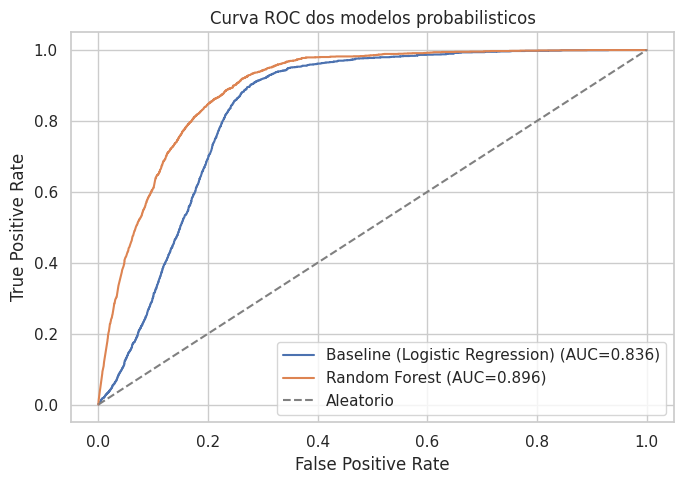

In [22]:
from sklearn.metrics import auc, roc_curve

roc_rows = []
roc_curves = {}

for name in ['Baseline (Logistic Regression)', 'Random Forest']:
    pipeline = model_configs[name]['pipeline']
    y_scores = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_scores)
    roc_auc = auc(fpr, tpr)
    roc_curves[name] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
    roc_rows.append({
        'Modelo': name,
        'AUC': roc_auc,
    })
    print(f'--- {name} ---')
    print(f'AUC: {roc_auc:.4f}')

roc_results_df = pd.DataFrame(roc_rows).sort_values(by='AUC', ascending=False)
roc_results_df.round(4)

plt.figure(figsize=(7, 5))
for name, values in roc_curves.items():
    plt.plot(values['fpr'], values['tpr'], label=f"{name} (AUC={values['auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Aleatorio')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC dos modelos probabilisticos')
plt.legend()
plt.tight_layout()
plt.show()


#### Conclusão da Parte 4

A avaliação dos modelos mostrou que, neste problema, não faz sentido olhar apenas para a accuracy. Como a base é muito desbalanceada, um modelo pode ter uma taxa alta de acerto simplesmente por classificar quase todos os registros como negativos. Foi exatamente o que aconteceu com o KNN: apesar de atingir 98,80% de accuracy, ele teve recall de apenas 2,07%, identificando somente 38 dos 1.833 casos positivos reais. Por esse motivo, ele não se mostrou adequado para uma aplicação de triagem.

A Regressão Logística e o Random Forest apresentaram resultados mais coerentes com o objetivo do trabalho. A Regressão Logística conseguiu identificar 74,36% dos casos positivos no conjunto de teste e teve recall médio de 91,46% na validação cruzada. Esse resultado mostra que o modelo tem boa capacidade de capturar casos positivos, embora ainda gere muitos falsos positivos, como indica sua precision de 3,65%.

O Random Forest teve o melhor desempenho geral no conjunto de teste. Ele alcançou recall de 77,41%, precision de 5,08% e F1 de 9,54%, capturando 1.419 dos 1.833 casos positivos reais. Além disso, também apresentou a maior AUC, com 89,62%, indicando melhor capacidade de separar casos positivos e negativos ao longo dos diferentes thresholds. Na validação cruzada, seu recall médio foi de 89,84%, muito próximo ao da Regressão Logística, mas com menor desvio padrão (0,29%), o que sugere um comportamento mais estável entre os folds.

Assim, considerando o objetivo do problema, o Random Forest foi o modelo mais adequado entre os avaliados. Ele conseguiu manter um recall alto, apresentou melhor precision, melhor F1 e maior AUC. A baixa precision ainda é um ponto de atenção, mas já era esperada por causa do forte desbalanceamento da base e do foco em reduzir falsos negativos.

Por fim, a regra de decisão teve papel importante nos resultados. Nos modelos probabilísticos, o threshold foi estimado na validação com base na curva precision-recall. Já no KNN, a decisão foi definida pelo valor de k. Em um problema de saúde, especialmente em triagem, o custo de deixar passar um possível caso positivo é maior do que o de gerar um falso positivo. Por isso, essas escolhas foram orientadas por um critério de sensibilidade, e não por chute.

---

## Bloco 5 - Fechamento

Mensagem final sugerida: em um problema de triagem em saúde com base fortemente desbalanceada, não basta olhar para accuracy. A escolha do modelo precisa ser guiada pelo custo do erro, especialmente pela necessidade de reduzir falsos negativos.

## Limitações e próximos passos

**Limitações:**
- base fortemente desbalanceada
- precision ainda baixa
- risco metodológico de vazamento em variáveis diagnósticas, se o recorte não for bem controlado
- necessidade de validação com especialista de domínio

**Próximos passos:**
- testar estratégias de balanceamento
- calibrar thresholds com critério clínico
- avaliar validação temporal
- explorar explicabilidade do modelo final